# K-Means Clustering

## Import required libraries

In [1]:
# if you run on a Windows platform, here exists a warning
# UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
import os
os.environ["OMP_NUM_THREADS"] = "3"


from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

In [2]:
root_path = Path(".").absolute()
data_path = root_path / "data"
data_path.mkdir(exist_ok=True)

%matplotlib inline

## K-Means on a synthetic dataset

<p>First, we need to set a random seed. Use <code>np.random.seed()</code> function, where the seed will be set to <code>0</code>.</p>

In [3]:
np.random.seed(0)

<p>Next, we will be making random clusters of points by using the <code>make_blobs</code> class. This class can take in many inputs, but we will be using these specific ones.</p>

<p><b><u>Input</u></b></p>
<ul>
    <li>
        <code>n_samples</code>: The total number of points equally divided among clusters.
        <ul><li>Value will be: <code>5000</code>.</li></ul>
    </li>
    <li>
        <code>centres</code>: The number of centres to generate, or the fixed centre locations.
        <ul><li>Value will be: <code>[[4, 4], [-2, -1], [2, -3], [1, 1]]</code>.</li></ul>
    </li>
    <li>
        <code>cluster_std</code>: The standard deviation of the clusters.
        <ul><li>Value will be: <code>0.9</code>.</li></ul>
    </li>
</ul>
<p><b><u>Output</u></b></p>
<ul>
    <li>
        <code>X</code>: Array of shape <code>[n_samples, n_features]</code> (Feature Matrix).
        <ul><li>The generated samples.</li></ul>
    </li>
    <li>
        <code>y</code>: Array of shape <code>[n_samples]</code> (Response Vector).
        <ul><li>The integer labels for cluster membership of each sample.</li></ul>
    </li>
</ul>

In [4]:
blobs_output: tuple[np.ndarray, np.ndarray] = make_blobs(n_samples=5000, centers=[[4, 4], [-2, -1], [2, -3], [1, 1]], cluster_std=0.9)
X, y = blobs_output

<p>Display the scatter plot of the randomly generated data.</p>

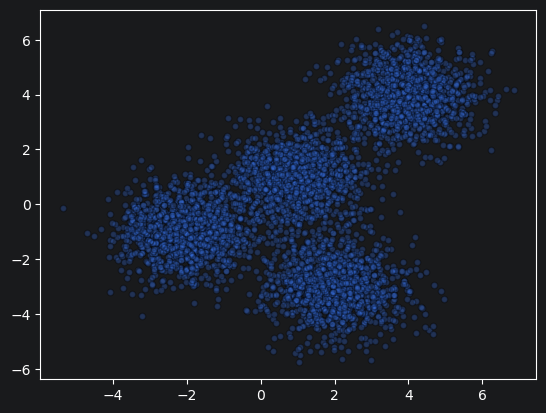

In [5]:
plt.scatter(X[:, 0], X[:, 1], marker='.', alpha=0.3, ec="k", s=80)

## Setting up k-means

<p>Now that we have our random data, let's set up our k-means Clustering.</p>
<p>The KMeans class has many parameters that can be used, but we will be using these three:</p>
<ul>
    <li>
        <code>init</code>: Initialization method of the centroids.
        <ul>
            <li>Value will be: <code>k-means++</code>.</li>
            <li><code>k-means++</code>: Select initial cluster centres for k-means clustering in a smart way to speed up convergence.</li>
        </ul>
    </li>
    <li>
        <code>n_clusters</code>: The number of clusters to form as well as the number of centroids to generate.
        <ul><li>Value will be: 4 (since we have 4 centres)</li></ul>
    </li>
    <li>
        <code>n_init</code>: Number of times the k-means algorithm will be run with different centroid seeds. The final results will be the best output of <code>n_init</code> consecutive runs in terms of inertia.
        <ul><li>Value will be: 12</li></ul>
    </li>
</ul>
<p>Initialize <code>KMeans</code> with these parameters, where the output variable is called <code>k_means</code>.</p>

In [6]:
k_means = KMeans(init="k-means++", n_clusters=4, n_init=12)

<p>Now let's fit the <code>KMeans</code> model with the feature matrix we created above <code>X</code>.</p>

In [7]:
k_means.fit(X)

KMeans(n_clusters=4, n_init=12)

<p>Let's get the label for each point in the model using the <code>k_means.labels_</code> attribute and save them as <code>k_means_labels</code>.</p>

In [8]:
k_means_labels = k_means.labels_
k_means_labels

array([0, 3, 3, ..., 1, 0, 0], shape=(5000,), dtype=int32)

<p>We will also get the coordinates of the cluster centers using <code>k_means.cluster_centers_</code> and save it as <code>k_means_cluster_centers</code>.</p>

In [9]:
k_means_cluster_centers = k_means.cluster_centers_
k_means_cluster_centers

array([[-2.03743147, -0.99782524],
       [ 3.97334234,  3.98758687],
       [ 0.96900523,  0.98370298],
       [ 1.99741008, -3.01666822]])

## Creating the Visual Plot

<p>Now that we have the random data generated and the k-means model initialized, let's plot the result and see what it looks like!</p>

[]

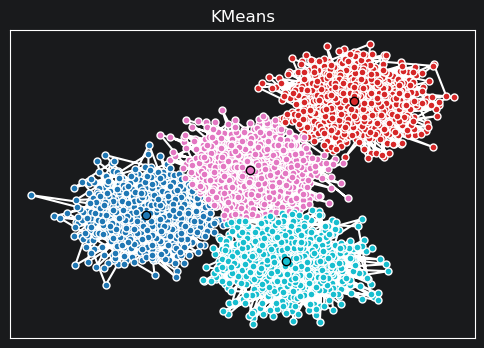

In [10]:
fig = plt.figure(figsize=(6, 4))

colors: np.ndarray = plt.cm.tab10(np.linspace(0, 1, len(set(k_means_labels))))

ax = fig.add_subplot(1, 1, 1)

for k, col in zip(range(len([[4, 4], [-2, -1], [2, -3], [1, 1]])), colors):
    my_members = k_means_labels == k
    cluster_center = k_means_cluster_centers[k]
    ax.plot(X[my_members, 0], X[my_members, 1], "w", markerfacecolor=col, marker=".", ms=10)
    ax.plot(cluster_center[0], cluster_center[1], "o", markerfacecolor=col, markeredgecolor="k", markersize=6)

ax.set_title("KMeans")
ax.set_xticks(())
ax.set_yticks(())

## Exercise 1

<p>Try to cluster the above dataset into a different number of clusters, say <code>k = 3</code>. Note the difference in the pattern generated.</p>

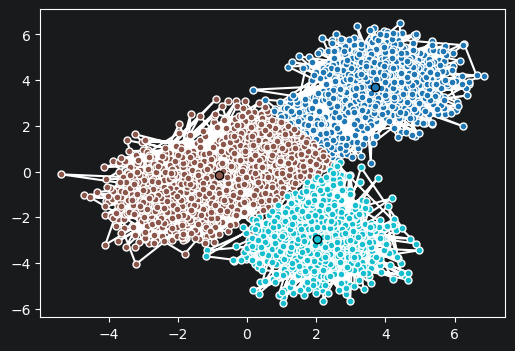

In [11]:
k_means3 = KMeans(init="k-means++", n_clusters=3, n_init=12)
k_means3.fit(X)

fig = plt.figure(figsize=(6, 4))
colors: np.ndarray = plt.cm.tab10(np.linspace(0, 1, len(set(k_means3.labels_))))
ax = fig.add_subplot(1, 1, 1)
for k, col in zip(range(len(k_means3.cluster_centers_)), colors):
    my_members = k_means3.labels_ == k
    cluster_center = k_means3.cluster_centers_[k]
    ax.plot(X[my_members, 0], X[my_members, 1], "w", markerfacecolor=col, marker=".", ms=10)
    ax.plot(cluster_center[0], cluster_center[1], "o", markerfacecolor=col, markeredgecolor="k", markersize=6)

## Exercise 2

<p>Try the same with <code>k = 5</code>.</p>

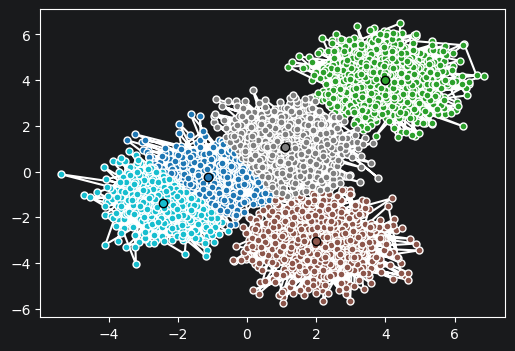

In [12]:
k_means5 = KMeans(init="k-means++", n_clusters=5, n_init=12)
k_means5.fit(X)

fig = plt.figure(figsize=(6, 4))
colors: np.ndarray = plt.cm.tab10(np.linspace(0, 1, len(set(k_means5.labels_))))
ax = fig.add_subplot(1, 1, 1)
for k, col in zip(range(len(k_means5.cluster_centers_)), colors):
    my_members = k_means5.labels_ == k
    cluster_center = k_means5.cluster_centers_[k]
    ax.plot(X[my_members, 0], X[my_members, 1], "w", markerfacecolor=col, marker=".", ms=10)
    ax.plot(cluster_center[0], cluster_center[1], "o", markerfacecolor=col, markeredgecolor="k", markersize=6)

## Customer Segmentation with k-means

<p>Imagine that you have a customer dataset, and you need to apply customer segmentation to this historical data. Customer segmentation is the practice of partitioning a customer base into groups of individuals that have similar characteristics. It is a significant strategy as a business can target these specific groups of customers and effectively allocate marketing resources. For example, one group might contain customers who are high-profit and low-risk, or more likely to purchase products, or subscribe to a service. A business task is to retain those customers.</p>

In [13]:
file = data_path / "Cust_Segmentation.csv"
df = pd.read_csv(file)
df.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2


## Pre-processing

<p>As you can see, <code>Address</code> in this dataset is a categorical variable. The k-means algorithm doesn't work directly with categorical variables because the Euclidean distance function isn't meaningful for them. You could one-hot encode the categorical feature, but for illustration purposes. Let's run k-means clustering without it.</p>

In [14]:
df = df.drop("Address", axis=1)
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 700 entries, 0 to 849
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer Id      700 non-null    int64  
 1   Age              700 non-null    int64  
 2   Edu              700 non-null    int64  
 3   Years Employed   700 non-null    int64  
 4   Income           700 non-null    int64  
 5   Card Debt        700 non-null    float64
 6   Other Debt       700 non-null    float64
 7   Defaulted        700 non-null    float64
 8   DebtIncomeRatio  700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 54.7 KB


<p>After dropping <code>NaNs</code> we still have 700 rows out of the original 849. Let's proceed with this smaller dataset.</p>

## Normalizing over the standard deviation

<p>Now let's normalize the dataset. But why do we need normalization in the first place? Normalization is a statistical method that helps mathematical-based algorithms to interpret features with different magnitudes and distributions equally, transforming the features so they have zero mean and standard deviation of one. We use <code>StandardScaler()</code> to normalize, or standardize our dataset.</p>

In [15]:
X = df.values[:, 1:]
Clus_dataSet = StandardScaler().fit_transform(X)

## Exercise 4

<p>Let's apply k-means to the dataset. Write the code to cluster the data with <code>k = 3</code>. Extract the cluster labels for this clustering process.</p>

In [16]:
k_means = KMeans(init="k-means++", n_clusters=3, n_init=12)
k_means.fit(X)
labels = k_means.labels_

## Insights

<p>We assign the k-means cluster labels to each row in the dataframe.</p>

In [17]:
df["Clus_km"] = labels

<p>We can easily check the centroid values by averaging the features in each cluster. These values indicate the central point of the cluster from the vantage point of the field in question.</p>

In [18]:
df.groupby("Clus_km").mean()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
Clus_km,,,,,,,,,
0,439.80226,32.775895,1.632768,6.169492,30.642185,1.003795,2.090910,0.284369,10.146893
1,374.00000,44.785714,3.000000,17.857143,219.714286,6.115429,11.546357,0.285714,8.064286
2,403.56129,41.103226,1.916129,15.135484,81.122581,3.024935,5.605258,0.180645,10.848387


<p>Now, let's look at the distribution of customers based on their education, age and income. We can choose to visualize this as a 2D scatter plot with <code>Age</code> on the x-axis, <code>Income</code> on the y-axis and the marker size representing education. The scatter points will be assigned different colors based on different class labels.</p>

Text(0, 0.5, 'Income')

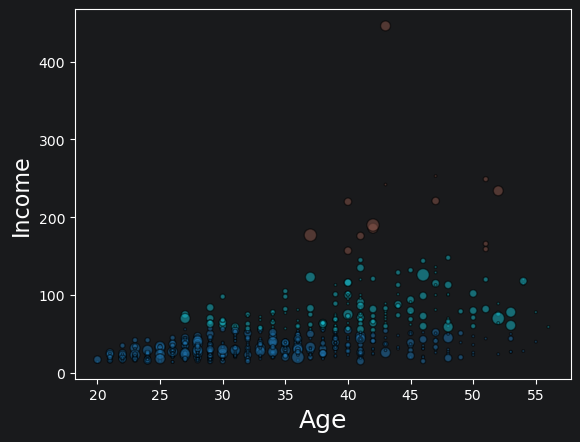

In [19]:
area = np.pi * (X[:, 1]) ** 2
plt.scatter(X[:, 0], X[:, 3], s=area, c=labels.astype(float), cmap="tab10", ec="k", alpha=0.5)
plt.xlabel("Age", fontsize=18)
plt.ylabel("Income", fontsize=16)

<p>We can also see this distribution in 3 dimensions for better understanding. Here, the education parameter will represent the third axis instead of the marker size.</p>

In [20]:
# need `nbformat>=4.2.0` here

fig = px.scatter_3d(X, x=1, y=0, z=3, opacity=0.7, color=labels.astype(float))
fig.update_traces(marker={"size": 5, "line": {"width": 0.25}}, showlegend=False)
fig.update_layout(coloraxis_showscale=False, width=1000, height=800, scene={"xaxis": {"title": "Education"}, "yaxis": {"title": "Age"}, "zaxis": {"title": "Income"}})

<p>K-means will partition your customers into mutually exclusive groups, for example, into 3 clusters. The customers in each cluster are similar to each other demographically.</p>

## Exercise 5

<p>Create a profile for each group, considering the common characteristics of each cluster based on your obsercations.</p>

Text(0.5, 1.02, 'Pairwise Scatter Plot with K-Means Clusters')

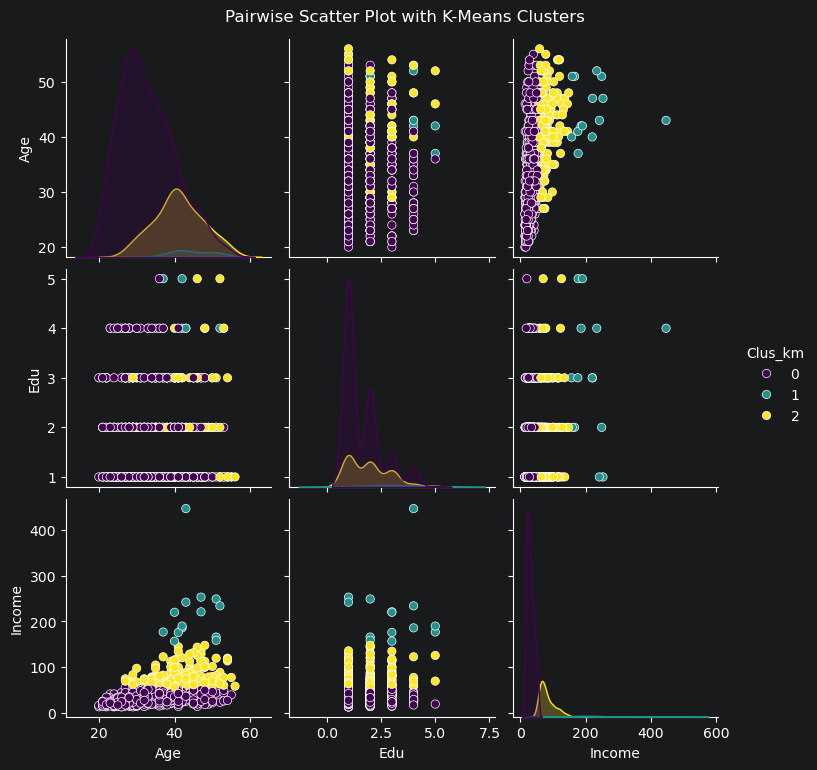

In [21]:
cust_df_sub = df.loc[:, ["Age", "Edu", "Income", "Clus_km"]].copy()
sns.pairplot(cust_df_sub, hue="Clus_km", palette="viridis", diag_kind="kde")
plt.suptitle("Pairwise Scatter Plot with K-Means Clusters", y=1.02)

****
This is the end of the file.
****